# 07 — Google Reviews Spatial Analysis

Joins Google Reviews sentiment data to NDVI values for all three cities and
runs Pearson correlation analysis. Mirrors the approach in notebook 05 but
uses intentional greenspace visit data rather than passive tweets.

**Inputs:** `data/processed/google_reviews_nyc.csv`, `google_reviews_mc.csv`,
`google_reviews_ch.csv`, NDVI rasters for all three cities  
**Output:** Correlation results and scatter plots per city

In [46]:
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.sample import sample_gen
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

## Step 1: Load Review Data

Load the sentiment-labeled Google Reviews produced in notebook 06 for all
three cities.

In [48]:
reviews_nyc = pd.read_csv("../data/processed/google_reviews_nyc.csv")
reviews_mc = pd.read_csv("../data/processed/google_reviews_mc.csv")
reviews_ch = pd.read_csv("../data/processed/google_reviews_ch.csv")


## Step 2: Convert to GeoDataFrames

Convert each reviews dataframe to a GeoPandas GeoDataFrame using WGS84
(EPSG:4326) so coordinates can be used to sample the NDVI rasters.

In [49]:
gdf_nyc = gpd.GeoDataFrame(
    reviews_nyc,
    geometry=gpd.points_from_xy(reviews_nyc["lon"], reviews_nyc["lat"]),
    crs="EPSG:4326"
)

gdf_nyc.head()

,text,rating,lat,lon,sentiment,sentiment_score,geometry
0,The High Line is a beautiful elevated walkway ...,5,40.747993,-74.004765,POSITIVE,1,POINT (-74.00476 40.74799)
1,Very cool park and something my wife and I alw...,5,40.747993,-74.004765,POSITIVE,1,POINT (-74.00476 40.74799)
2,I had been wanting to visit this place for a w...,5,40.747993,-74.004765,POSITIVE,1,POINT (-74.00476 40.74799)
3,"I absolutely love walking on the highline, whe...",5,40.747993,-74.004765,POSITIVE,1,POINT (-74.00476 40.74799)
4,What an amazing place! An old rail track conve...,5,40.747993,-74.004765,POSITIVE,1,POINT (-74.00476 40.74799)


## Step 3: Open NDVI Rasters

Load city-specific Sentinel-2 derived NDVI rasters for NYC, Maricopa County,
and Cook County (Chicago). Each city has its own raster file since they cover
different geographic extents.

In [50]:
gdf_mc = gpd.GeoDataFrame(
    reviews_mc,
    geometry=gpd.points_from_xy(reviews_mc["lon"], reviews_mc["lat"]),
    crs="EPSG:4326"
)

gdf_mc.head()

,text,rating,lat,lon,sentiment,sentiment_score,geometry
0,Hole in the Rock is a super cool spot and defi...,5,33.456487,-111.945261,POSITIVE,1,POINT (-111.94526 33.45649)
1,Short hike up to the viewing area with amazing...,5,33.456487,-111.945261,POSITIVE,1,POINT (-111.94526 33.45649)
2,This was fun. Easy to walk and climb. Very s...,5,33.456487,-111.945261,POSITIVE,1,POINT (-111.94526 33.45649)
3,Worth the visit when in PHX. Easy enough walk ...,5,33.456487,-111.945261,POSITIVE,1,POINT (-111.94526 33.45649)
4,Beautiful park for hiking walking biking. You ...,5,33.456487,-111.945261,POSITIVE,1,POINT (-111.94526 33.45649)


In [51]:
gdf_ch = gpd.GeoDataFrame(
    reviews_ch,
    geometry=gpd.points_from_xy(reviews_ch["lon"], reviews_ch["lat"]),
    crs="EPSG:4326"
)

gdf_ch.head()

,text,rating,lat,lon,sentiment,sentiment_score,geometry
0,"Went here with my family, we really liked it. ...",5,41.891863,-87.605094,POSITIVE,1,POINT (-87.60509 41.89186)
1,"Navy Pier is such a nice area to shop, walk ar...",5,41.891863,-87.605094,POSITIVE,1,POINT (-87.60509 41.89186)
2,"Great place for kids, they have a hotel now by...",5,41.891863,-87.605094,POSITIVE,1,POINT (-87.60509 41.89186)
3,We absolutely love Navy Pier and make it a mus...,5,41.891863,-87.605094,POSITIVE,1,POINT (-87.60509 41.89186)
4,Such a great place to visit both as a visitor ...,5,41.891863,-87.605094,POSITIVE,1,POINT (-87.60509 41.89186)


## Step 4: Sample NDVI at Review Locations

For each city, extract the NDVI value at the coordinates of each greenspace
location. Reviews from the same place share the same NDVI value since they
were collected at the place centroid.

In [78]:
ndvi_path_nyc = "../data/raw/ndvi/nyc_ndvi_2023.tif"

src_nyc = rasterio.open(ndvi_path_nyc)

ndvi_path_mc = "../data/raw/ndvi/maricopa_ndvi_2023.tif"

src_mc = rasterio.open(ndvi_path_mc)

ndvi_path_ch = "../data/raw/ndvi/cook_county_ndvi_2023.tif"

src_ch = rasterio.open(ndvi_path_ch)

In [80]:
coords_nyc = [(x,y) for x,y in zip(gdf_nyc["lon"], gdf_nyc["lat"])]

ndvi_values_nyc = [x[0] for x in src_nyc.sample(coords_nyc)]

gdf_nyc["ndvi"] = ndvi_values_nyc

gdf_nyc.head()

,text,rating,lat,lon,sentiment,sentiment_score,geometry,ndvi
0,The High Line is a beautiful elevated walkway ...,5,40.747993,-74.004765,POSITIVE,1,POINT (-74.00476 40.74799),0.386193
1,Very cool park and something my wife and I alw...,5,40.747993,-74.004765,POSITIVE,1,POINT (-74.00476 40.74799),0.386193
2,I had been wanting to visit this place for a w...,5,40.747993,-74.004765,POSITIVE,1,POINT (-74.00476 40.74799),0.386193
3,"I absolutely love walking on the highline, whe...",5,40.747993,-74.004765,POSITIVE,1,POINT (-74.00476 40.74799),0.386193
4,What an amazing place! An old rail track conve...,5,40.747993,-74.004765,POSITIVE,1,POINT (-74.00476 40.74799),0.386193


In [81]:
coords_mc = [(x,y) for x,y in zip(gdf_mc["lon"], gdf_mc["lat"])]

ndvi_values_mc = [x[0] for x in src_mc.sample(coords_mc)]

gdf_mc["ndvi"] = ndvi_values_mc

gdf_mc.head()

,text,rating,lat,lon,sentiment,sentiment_score,geometry,ndvi
0,Hole in the Rock is a super cool spot and defi...,5,33.456487,-111.945261,POSITIVE,1,POINT (-111.94526 33.45649),0.090307
1,Short hike up to the viewing area with amazing...,5,33.456487,-111.945261,POSITIVE,1,POINT (-111.94526 33.45649),0.090307
2,This was fun. Easy to walk and climb. Very s...,5,33.456487,-111.945261,POSITIVE,1,POINT (-111.94526 33.45649),0.090307
3,Worth the visit when in PHX. Easy enough walk ...,5,33.456487,-111.945261,POSITIVE,1,POINT (-111.94526 33.45649),0.090307
4,Beautiful park for hiking walking biking. You ...,5,33.456487,-111.945261,POSITIVE,1,POINT (-111.94526 33.45649),0.090307


In [82]:
coords_ch = [(x,y) for x,y in zip(gdf_ch["lon"], gdf_ch["lat"])]

ndvi_values_ch = [x[0] for x in src_ch.sample(coords_ch)]

gdf_ch["ndvi"] = ndvi_values_ch

gdf_ch.head()

,text,rating,lat,lon,sentiment,sentiment_score,geometry,ndvi
0,"Went here with my family, we really liked it. ...",5,41.891863,-87.605094,POSITIVE,1,POINT (-87.60509 41.89186),0.009302
1,"Navy Pier is such a nice area to shop, walk ar...",5,41.891863,-87.605094,POSITIVE,1,POINT (-87.60509 41.89186),0.009302
2,"Great place for kids, they have a hotel now by...",5,41.891863,-87.605094,POSITIVE,1,POINT (-87.60509 41.89186),0.009302
3,We absolutely love Navy Pier and make it a mus...,5,41.891863,-87.605094,POSITIVE,1,POINT (-87.60509 41.89186),0.009302
4,Such a great place to visit both as a visitor ...,5,41.891863,-87.605094,POSITIVE,1,POINT (-87.60509 41.89186),0.009302


## Step 5: Drop Missing Values and Run Correlation

Remove rows where NDVI or sentiment score is null, then compute Pearson
correlation between NDVI and sentiment score for each city.

**Results:**
| City | Pearson r | p-value | Significant? |
|------|-----------|---------|--------------|
| NYC | 0.096 | 0.353 | No |
| Maricopa | 0.160 | 0.244 | No |
| Chicago | 0.125 | 0.215 | No |

No city shows a statistically significant correlation. Sample sizes are small
(~90 reviews per city), which limits statistical power. The overwhelming
positivity of reviews (91-97% positive) also compresses the sentiment range,
making correlation difficult to detect even if a true relationship exists.

In [83]:
gdf_nyc = gdf_nyc.dropna(subset=["ndvi", "sentiment_score"])
gdf_mc = gdf_mc.dropna(subset=["ndvi", "sentiment_score"])
gdf_ch = gdf_ch.dropna(subset=["ndvi", "sentiment_score"])

In [84]:
corr_nyc, pval_nyc = pearsonr(gdf_nyc["ndvi"], gdf_nyc["sentiment_score"])

print("Correlation:", corr_nyc)
print("P-value:", pval_nyc)

Correlation: 0.09642466318071516
P-value: 0.3525999717492055


## Step 6: Visualize NDVI vs. Sentiment per City

Scatter plots for each city. The binary/near-binary distribution of sentiment
scores (reviews are almost entirely POSITIVE = 1) creates a ceiling effect
visible in all three plots — most points cluster at sentiment = 1.0 regardless
of NDVI value.

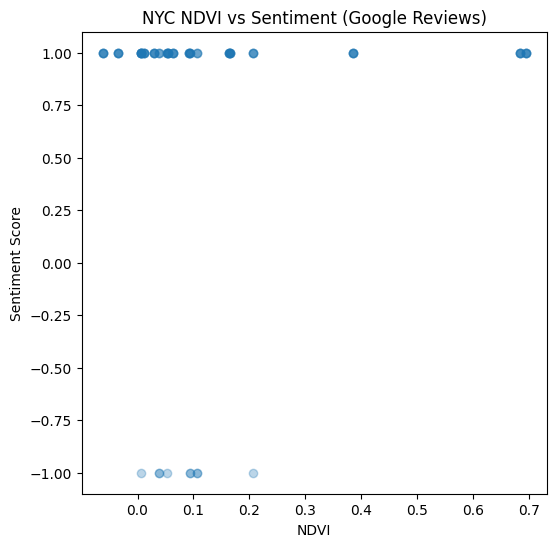

In [85]:
plt.figure(figsize=(6,6))
plt.scatter(gdf_nyc["ndvi"], gdf_nyc["sentiment_score"], alpha=0.3)
plt.xlabel("NDVI")
plt.ylabel("Sentiment Score")
plt.title("NYC NDVI vs Sentiment (Google Reviews)")
plt.show()

In [86]:
corr, pval = pearsonr(gdf_mc["ndvi"], gdf_mc["sentiment_score"])

print("Correlation:", corr)
print("P-value:", pval)

Correlation: 0.1597199613308782
P-value: 0.24409838705262665


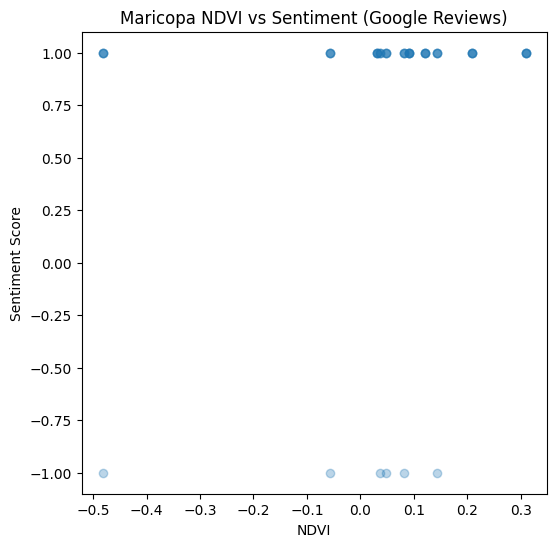

In [89]:
plt.figure(figsize=(6,6))
plt.scatter(gdf_mc["ndvi"], gdf_mc["sentiment_score"], alpha=0.3)
plt.xlabel("NDVI")
plt.ylabel("Sentiment Score")
plt.title("Maricopa NDVI vs Sentiment (Google Reviews)")
plt.show()

In [87]:
corr, pval = pearsonr(gdf_ch["ndvi"], gdf_ch["sentiment_score"])

print("Correlation:", corr)
print("P-value:", pval)

Correlation: 0.12505688974080936
P-value: 0.21507916879845598


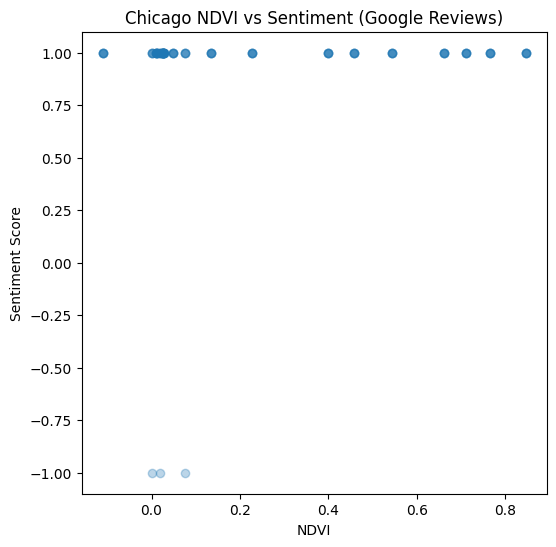

In [90]:
plt.figure(figsize=(6,6))
plt.scatter(gdf_ch["ndvi"], gdf_ch["sentiment_score"], alpha=0.3)
plt.xlabel("NDVI")
plt.ylabel("Sentiment Score")
plt.title("Chicago NDVI vs Sentiment (Google Reviews)")
plt.show()